#### Student Pass Prediction

X_train_scaled:
    hours_studied  attendance
0        0.000000    0.000000
1        0.166667    0.166667
2        0.250000    0.233333
3        0.333333    0.333333
4        0.416667    0.433333
5        0.500000    0.500000
6        0.583333    0.566667
7        0.666667    0.666667
8        0.750000    0.766667
9        0.833333    0.833333
10       0.916667    0.900000
11       1.000000    1.000000
Logistic Regression Model Output (z):
0    -0.500000
1    -0.333333
2    -0.263333
3    -0.166667
4    -0.070000
5     0.000000
6     0.070000
7     0.166667
8     0.263333
9     0.333333
10    0.403333
11    0.500000
dtype: float64
y_pred:

0     0.377541
1     0.417430
2     0.434544
3     0.458430
4     0.482507
5     0.500000
6     0.517493
7     0.541570
8     0.565456
9     0.582570
10    0.599488
11    0.622459
dtype: float64
Predicted: Fail
Predicted: Fail
Predicted: Fail
Predicted: Fail
Predicted: Fail
Predicted: Pass
Predicted: Pass
Predicted: Pass
Predicted: Pass
Predicted: Pa

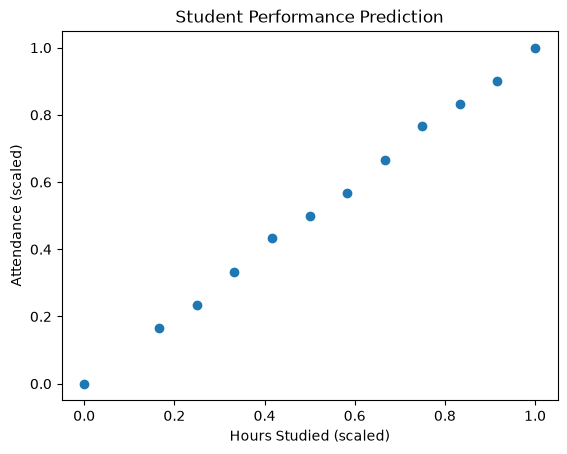

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('student_data.csv')
X = df[["hours_studied", "attendance"]]
y = df["passed"]

X_train = X.iloc[:12]
y_train = y.iloc[:12]

X_test = X.iloc[12:]
y_test = y.iloc[12:]

# feature scaling (true min-max normalization: (X - min) / (max - min))
hours_min = X_train["hours_studied"].min()
hours_max = X_train["hours_studied"].max()
attendance_min = X_train["attendance"].min()
attendance_max = X_train["attendance"].max()

X_train_scaled = X_train.copy()
X_train_scaled["hours_studied"] = (
    (X_train["hours_studied"] - hours_min) / (hours_max - hours_min)
)
X_train_scaled["attendance"] = (
    (X_train["attendance"] - attendance_min) / (attendance_max - attendance_min)
)

print("X_train_scaled:")
print(X_train_scaled)

w1 = 0.2
w2 = 0.8
b = -0.5  # fixed from 0.5 -> -0.5 so z can actually go negative

# calculate z (z = w1 * hours_studied + w2 * attendance + b)
z = w1 * X_train_scaled["hours_studied"] + w2 * X_train_scaled["attendance"] + b
print("Logistic Regression Model Output (z):")
print(z)

# calculate the sigmoid of z
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

y_pred = sigmoid(z)
print("y_pred:\n")
print(y_pred)

# Decision Boundary: If y_pred >= 0.5, predict 1 (pass), else predict 0 (fail)
for i in y_pred:
    if i >= 0.50:
        print("Predicted: Pass")
    else:
        print("Predicted: Fail")

plt.plot(X_train_scaled["hours_studied"], X_train_scaled["attendance"], 'o')
plt.xlabel("Hours Studied (scaled)")
plt.ylabel("Attendance (scaled)")
plt.title("Student Performance Prediction")
plt.show()

w_final: [13.71706684 12.27134798]
b_final: -11.933168333641536


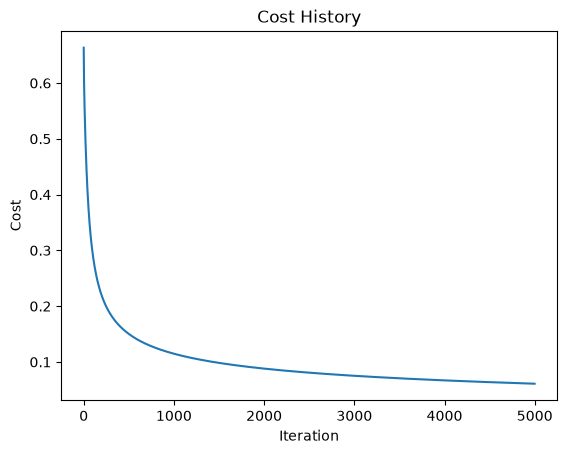

Final cost: 0.06102006318099734
First cost: 0.6633547797560188


In [2]:
#Gradient Descent Implementation
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def compute_cost(X, y, w, b):
    m = X.shape[0]
    z = X @ w + b
    f = sigmoid(z)
    eps = 1e-15
    cost = -np.mean(y * np.log(f + eps) + (1 - y) * np.log(1 - f + eps))
    return cost

def compute_gradient(X, y, w, b):
    m = X.shape[0]
    z = X @ w + b
    f = sigmoid(z)
    error = f - y
    dj_dw = (X.T @ error) / m
    dj_db = np.sum(error) / m
    return dj_dw, dj_db
def gradient_descent(X, y, w_in, b_in, alpha, iterations, compute_cost, compute_gradient):
    w = w_in.copy()
    b = b_in
    cost_history = []

    for i in range(iterations):
        dj_dw, dj_db = compute_gradient(X, y, w, b)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        cost_history.append(compute_cost(X, y, w, b))

    return w, b, cost_history
X_train_arr = X_train_scaled.values
y_train_arr = y_train.values.astype(float)
w_init = np.zeros(X_train_arr.shape[1])
b_init = 0.0
alpha = 0.5
iterations = 5000

w_final, b_final, cost_history = gradient_descent(
    X_train_arr, y_train_arr, w_init, b_init, alpha, iterations,
    compute_cost, compute_gradient
)

print("w_final:", w_final)
print("b_final:", b_final)  

plt.plot(cost_history)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Cost History")
plt.show()

print("Final cost:", cost_history[-1])
print("First cost:", cost_history[0])

In [3]:
z_learned = X_train_arr @ w_final + b_final
y_pred_learned = sigmoid(z_learned)
predicted_labels = (y_pred_learned >= 0.5).astype(int)
accuracy = (predicted_labels == y_train_arr).mean()
print(f"Accuracy: {accuracy:.2%}")

Accuracy: 100.00%


In [8]:
X_test_scaled = X_test.copy()
X_test_scaled["hours_studied"] = (
    (X_test["hours_studied"] - hours_min) / (hours_max - hours_min)
)
X_test_scaled["attendance"] = (
    (X_test["attendance"] - attendance_min) / (attendance_max - attendance_min)
)
print(X_test_scaled)

    hours_studied  attendance
12       1.083333    1.100000
13       1.166667    1.166667
14       1.250000    1.233333
15       1.333333    1.333333


In [9]:
X_test_arr = X_test_scaled.values
y_test_arr = y_test.values.astype(float)

z_test = X_test_arr @ w_final + b_final
y_pred_test = sigmoid(z_test)
predicted_test_labels = (y_pred_test >= 0.5).astype(int)

test_accuracy = (predicted_test_labels == y_test_arr).mean()
print(f"Test Accuracy: {test_accuracy:.2%}")

Test Accuracy: 100.00%
